In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.legend_handler import HandlerTuple
from scipy.special import rel_entr
import networkx as nx
from sklearn.metrics import r2_score

import os
import json

from biological_fuzzy_logic_networks.manuscripts_functions.colors import perturbation_models_dict
from biological_fuzzy_logic_networks.manuscripts_functions.metrics import compute_scalar_mmd, wasserstein_distance

In [2]:
fontsize = 12

In [3]:
sns.set_theme(font="Arial", style="ticks", rc={"font.size": fontsize,"axes.titlesize":fontsize,"axes.labelsize":fontsize, 
                                               "xtick.labelsize": fontsize, "ytick.labelsize": fontsize, "legend.fontsize": fontsize})
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.size'] = fontsize


In [4]:
folder = "/Users/adr/Box/BioFuzzNet/BFN/Model/init_dists/Output/test"
config_folder = "/Users/adr/Box/BioFuzzNet/BFN/Model/init_dists/Configs/"

In [5]:
n_repeats = 5
dists = ["normal", "bimodal", "uniform"]

data = []

for j in range(n_repeats):
    for dist in dists:
        exp_data = pd.read_csv(f"{folder}{dist}_repeat_{j}_predictions.csv", index_col=1)
        exp_data = exp_data.rename(columns={"Unnamed: 0":"model"})
        exp_data["dist"] = dist
        exp_data["repeat"] = j
        data.append(exp_data)
        
        

In [6]:
data = pd.concat(data)

In [7]:
data

,model,mek12,erk12,mkk4,jnk12,ikk,ikb,ras,map3k7,pi3k,map3k1,akt,p38,hsp27,dist,repeat
0,teacher_true,0.630001,0.499055,0.095602,0.064174,0.379622,0.201788,0.699952,0.399697,0.966933,0.406554,0.996164,0.012928,0.003440,normal,0
1,teacher_true,0.595064,0.451102,0.047093,0.022848,0.257682,0.114495,0.676707,0.244401,0.924213,0.399435,0.976420,0.002947,0.000596,normal,0
2,teacher_true,0.213016,0.101186,0.189221,0.144630,0.503600,0.325025,0.348770,0.485161,0.825561,0.520295,0.865628,0.039498,0.005109,normal,0
3,teacher_true,0.497568,0.333088,0.050916,0.030140,0.262764,0.117595,0.608421,0.313809,0.912870,0.336590,0.968139,0.004528,0.000727,normal,0
4,teacher_true,0.121204,0.052108,0.122941,0.086387,0.397330,0.217006,0.226376,0.433771,0.818181,0.441591,0.854357,0.019603,0.001872,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,nohill_random_input,0.129388,0.076060,0.510799,0.516600,0.859249,0.792612,0.210675,0.841993,0.800783,0.767469,0.710081,0.287252,0.148232,uniform,4
996,nohill_random_input,0.351918,0.234131,0.817147,0.766797,0.933220,0.903048,0.487483,0.913373,0.746223,0.954974,0.637657,0.639600,0.485482,uniform,4
997,nohill_random_input,0.013700,0.007587,0.668523,0.727901,0.942381,0.916970,0.024604,0.914470,0.863353,0.839622,0.798585,0.474242,0.297990,uniform,4
998,nohill_random_input,0.683535,0.559976,0.048865,0.033102,0.383586,0.260001,0.781176,0.350162,0.967705,0.321268,0.955204,0.006411,0.002319,uniform,4


In [8]:
output_markers = [c for c in data.columns if c not in ["model", "dist", "repeat"]]
markers = [
        "mek12",
        "erk12",
        "mkk4",
        "jnk12",
        "ikk",
        "ikb",
        "ras",
        "map3k7",
        "igf1",
        "pi3k",
        "il1a",
        "map3k1",
        "tgfa",
        "tnfa",
        "akt",
        "p38",
        "hsp27",
    ]

In [9]:
def compute_MSE(data, true_model_name: str):
    true = data[data["model"]==true_model_name]
    true = true.drop(["model", "dist", "repeat"], axis=1)
    true["repeat"] = 0 # So that repeat doesn't get lost when x-true. This doesn't cancel out the different repeats
    data = data.groupby("model").apply(lambda x: ((x-true)**2).groupby("repeat").mean())
    data = data.drop(["model", "dist"], axis=1)
    data = data.reset_index("model", drop=False)
    
    return data

def compute_R2(data, true_model_name: str, markers=output_markers):
    true = data[data["model"]==true_model_name]
    data = data.groupby("model").apply(lambda x: pd.Series([r2_score(true[m], x[m]) for m in markers]))
    data.columns=markers
    data[data==np.inf] = 0
    data = data.reset_index(drop=False)
    
    return data


def compute_MMD(data, true_model_name: str, markers=output_markers):
    true = data.loc[data["model"]==true_model_name, markers]
    data = data.groupby("model").apply(lambda x: compute_scalar_mmd(true, x[markers]))
    data = data.reset_index(drop=False)
    
    return data

def compute_wasserstein(data, true_model_name: str, markers=output_markers):
    true = data.loc[data["model"]==true_model_name, markers]
    data = data.groupby("model").apply(lambda x: wasserstein_distance(true, x[markers]))
    data = data.reset_index(drop=False)
    
    return data

In [10]:
data["model"].unique()

array(['teacher_true', 'student_same_input', 'student_random_input',
       'nohill_same_input', 'nohill_random_input'], dtype=object)

In [11]:
data_MSE = data.groupby(["dist"]).apply(compute_MSE, true_model_name="teacher_true").reset_index()
data_R2 = data.groupby(["dist", "repeat"]).apply(compute_R2, true_model_name="teacher_true").reset_index().drop("level_2", axis=1)

data_MMD = data.groupby(["dist", "repeat"]).apply(compute_MMD, true_model_name="teacher_true").reset_index().drop("level_2", axis=1).rename(columns={0: "MMD"})
data_EMD = data.groupby(["dist", "repeat"]).apply(compute_wasserstein, true_model_name="teacher_true").reset_index().drop("level_2", axis=1).rename(columns={0: "EMD"})
data_EMD["EMD"] = data_EMD["EMD"].astype(float)


In [12]:
avg_data_MSE = data_MSE.groupby(["dist", "model", "repeat"]).mean().reset_index()
avg_data_R2 = data_R2.groupby(["dist", "model", "repeat"]).mean().reset_index()
avg_data_MSE = avg_data_MSE.melt(id_vars=["dist", "model", "repeat"], value_name="Network MSE", var_name="node")
avg_data_R2 = avg_data_R2.melt(id_vars=["dist", "model", "repeat"], value_name="Network R2", var_name="node")
avg_data_MSE = avg_data_MSE.groupby(["dist", "model", "repeat"]).mean().reset_index()
avg_data_R2 = avg_data_R2.groupby(["dist", "model", "repeat"]).mean().reset_index()

avg_data_MSE

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_53623/250985440.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  avg_data_MSE = avg_data_MSE.groupby(["dist", "model", "repeat"]).mean().reset_index()
/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_53623/250985440.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  avg_data_R2 = avg_data_R2.groupby(["dist", "model", "repeat"]).mean().reset_index()


,dist,model,repeat,Network MSE
0,bimodal,nohill_random_input,0,0.299052
1,bimodal,nohill_random_input,1,0.275105
2,bimodal,nohill_random_input,4,0.290115
3,bimodal,nohill_random_input,9,0.300046
4,bimodal,nohill_random_input,16,0.296486
...,...,...,...,...
70,uniform,teacher_true,0,0.000000
71,uniform,teacher_true,1,0.000000
72,uniform,teacher_true,4,0.000000
73,uniform,teacher_true,9,0.000000


# MSE, same inputs

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_53623/3610378606.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set(xticklabels=["Student same input", "NoHill same input"])


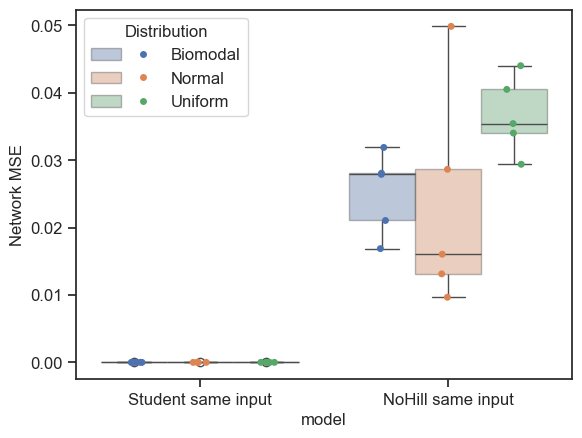

In [13]:
plt_data = avg_data_MSE[avg_data_MSE["model"].isin(['student_same_input', 'nohill_same_input'])]
ax = sns.boxplot(data=plt_data, x="model", y="Network MSE", hue="dist", boxprops={'alpha': 0.4},
                order=['student_same_input', 'nohill_same_input'])
sns.stripplot(x='model', y='Network MSE', data=plt_data, hue="dist", dodge=True, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[(handles[0], handles[3]),(handles[1], handles[4]), (handles[2], handles[5])],
          labels=['Biomodal', 'Normal', "Uniform"],
          loc='upper left', handlelength=4, title="Distribution",
          handler_map={tuple: HandlerTuple(ndivide=None)})
ax.set(xticklabels=["Student same input", "NoHill same input"])
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Init_distributions_MSE_boxplot_same_inputs_three_dists.pdf", bbox_inches="tight")

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_53623/2016055463.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set(xticklabels=["Student same input"])


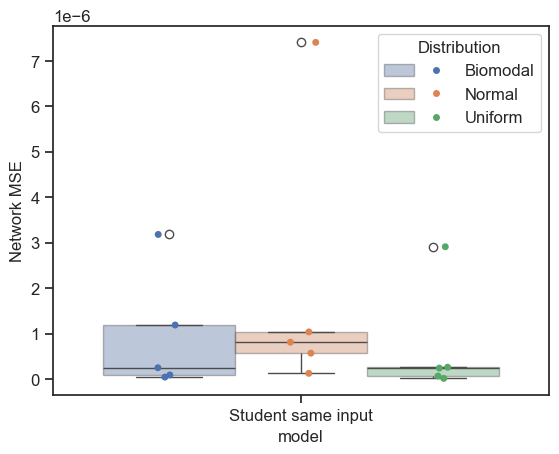

In [14]:
plt_data = avg_data_MSE[avg_data_MSE["model"]=='student_same_input']
ax = sns.boxplot(data=plt_data, x="model", y="Network MSE", hue="dist", boxprops={'alpha': 0.4})
sns.stripplot(x='model', y='Network MSE', data=plt_data, hue="dist", dodge=True, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[(handles[0], handles[3]),(handles[1], handles[4]), (handles[2], handles[5])],
          labels=['Biomodal', 'Normal', "Uniform"], title="Distribution",
          loc='upper right', handlelength=4,
          handler_map={tuple: HandlerTuple(ndivide=None)})
ax.set(xticklabels=["Student same input"])
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Init_distributions_MSE_boxplot_student_same_inputs_three_dists.pdf", bbox_inches="tight")

# R2, same inputs

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_53623/1534694484.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set(xticklabels=["Student same input", "NoHill same input"])


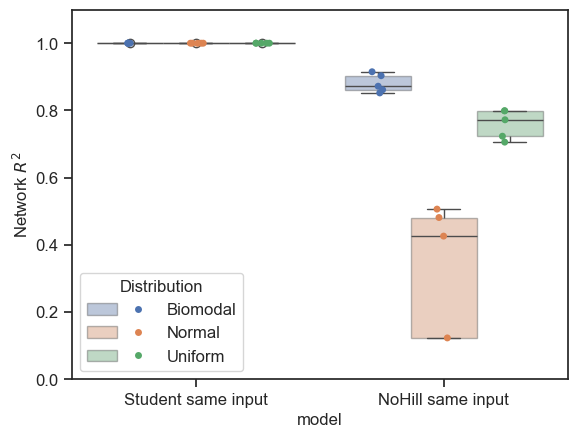

In [30]:
plt_data = avg_data_R2[avg_data_R2["model"].isin(['student_same_input', 'nohill_same_input'])]
ax = sns.boxplot(data=plt_data, x="model", y="Network R2", hue="dist", boxprops={'alpha': 0.4},
                order=['student_same_input', 'nohill_same_input'])
sns.stripplot(x='model', y='Network R2', data=plt_data, hue="dist", dodge=True, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[(handles[0], handles[3]),(handles[1], handles[4]), (handles[2], handles[5])],
          labels=['Biomodal', 'Normal', "Uniform"], title="Distribution",
          loc='lower left', handlelength=4,
          handler_map={tuple: HandlerTuple(ndivide=None)})
ax.set(xticklabels=["Student same input", "NoHill same input"])
plt.ylim(0,1.1)
plt.ylabel("Network $R^2$")
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Init_distributions_R2_boxplot_same_inputs_three_dists.pdf", bbox_inches="tight")

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_53623/3318055.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set(xticklabels=["Student same input"])


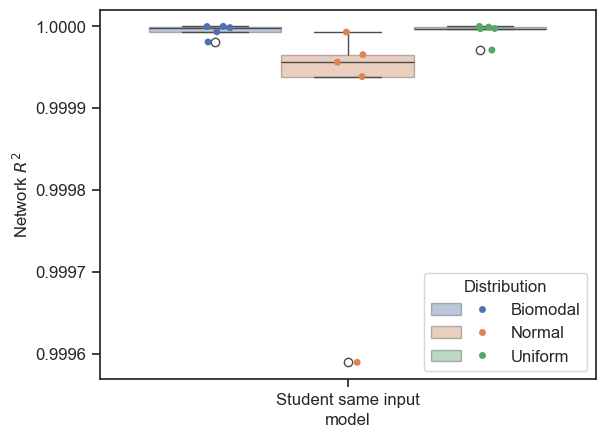

In [31]:
plt_data = avg_data_R2[avg_data_R2["model"]=='student_same_input']
ax=sns.boxplot(data=plt_data, x="model", y="Network R2", hue="dist", boxprops={'alpha': 0.4})
sns.stripplot(x='model', y='Network R2', data=plt_data, hue="dist", dodge=True, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[(handles[0], handles[3]),(handles[1], handles[4]), (handles[2], handles[5])],
          labels=['Biomodal', 'Normal', "Uniform"], title="Distribution",
          loc='lower right', handlelength=4,
          handler_map={tuple: HandlerTuple(ndivide=None)})
ax.set(xticklabels=["Student same input"])
plt.ylabel("Network $R^2$")

plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Init_distributions_R2_boxplot_student_same_inputs_three_dists.pdf", bbox_inches="tight")

# MMD, all random and same inputs

In [17]:
data_MMD

,dist,repeat,model,MMD
0,bimodal,0,nohill_random_input,2.471883e-01
1,bimodal,0,nohill_same_input,7.784816e-02
2,bimodal,0,student_random_input,1.668214e-01
3,bimodal,0,student_same_input,0.000000e+00
4,bimodal,0,teacher_true,0.000000e+00
...,...,...,...,...
70,uniform,4,nohill_random_input,3.815171e-02
71,uniform,4,nohill_same_input,4.143537e-02
72,uniform,4,student_random_input,1.176139e-03
73,uniform,4,student_same_input,7.450581e-08


/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_53623/1483810261.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels=["Student same input", "NoHill same input",


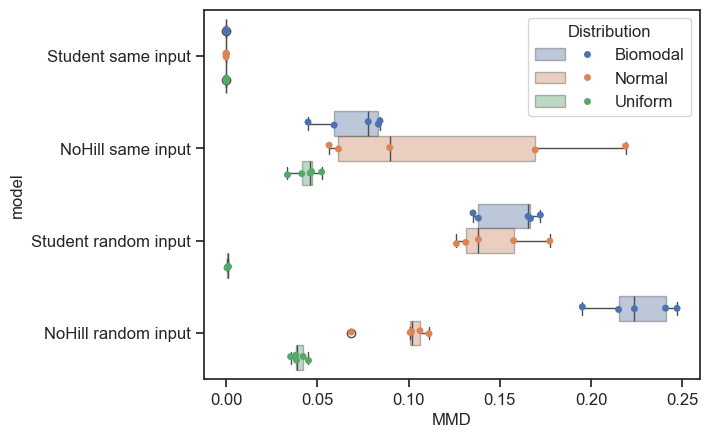

In [18]:
plt_data = data_MMD[data_MMD["model"]!="teacher_true"]
ax=sns.boxplot(data=plt_data, y="model", x="MMD", hue="dist", boxprops={'alpha': 0.4},
              order=[
                  "student_same_input",
                  "nohill_same_input",
                  "student_random_input",
                  "nohill_random_input"
              ])
sns.stripplot(y='model', x='MMD', data=plt_data, hue="dist", dodge=True, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[(handles[0], handles[3]),(handles[1], handles[4]), (handles[2], handles[5])],
          labels=['Biomodal', 'Normal', "Uniform"], title="Distribution",
          loc='upper right', handlelength=4,
          handler_map={tuple: HandlerTuple(ndivide=None)})
ax.set_yticklabels(labels=["Student same input", "NoHill same input", 
                           "Student random input", "NoHill random input"])

plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Init_distributions_MMD_boxplot_all_inputs_three_dists.pdf", bbox_inches="tight")

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_53623/3649511327.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels=["Student same input", "Student random input"])


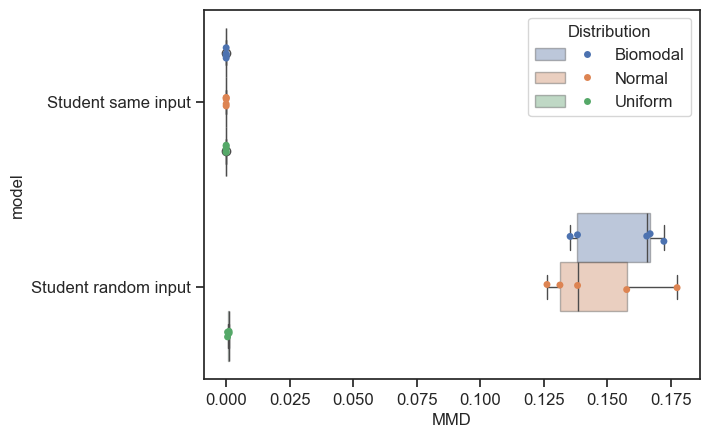

In [32]:
plt_data = data_MMD[data_MMD["model"].isin(['student_same_input', 'student_random_input'])]
ax=sns.boxplot(data=plt_data, y="model", x="MMD", hue="dist", boxprops={'alpha': 0.4},
              order=['student_same_input', 'student_random_input'])
sns.stripplot(y='model', x='MMD', data=plt_data, hue="dist", dodge=True, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[(handles[0], handles[3]),(handles[1], handles[4]), (handles[2], handles[5])],
          labels=['Biomodal', 'Normal', "Uniform"], title="Distribution",
          loc='upper right', handlelength=4,
          handler_map={tuple: HandlerTuple(ndivide=None)})
ax.set_yticklabels(labels=["Student same input", "Student random input"])

plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Init_distributions_MMD_boxplot_same_inputs_three_dists.pdf", bbox_inches="tight")

# EMD, all random and same inputs

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_53623/3425824307.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels=["Student same input", "NoHill same input",


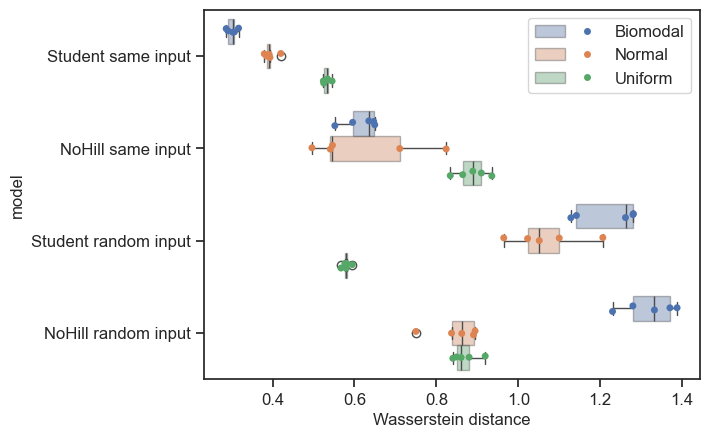

In [36]:
plt_data = data_EMD[data_EMD["model"]!="teacher_true"]
ax=sns.boxplot(data=plt_data, y="model", x="EMD", hue="dist", boxprops={'alpha': 0.4},
               order=[
                  "student_same_input",
                  "nohill_same_input",
                  "student_random_input",
                  "nohill_random_input"
              ])
sns.stripplot(y='model', x='EMD', data=plt_data, hue="dist", dodge=True, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[(handles[0], handles[3]),(handles[1], handles[4]), (handles[2], handles[5])],
          labels=['Biomodal', 'Normal', "Uniform"],
          loc='upper right', handlelength=4,
          handler_map={tuple: HandlerTuple(ndivide=None)})
ax.set_yticklabels(labels=["Student same input", "NoHill same input", 
                           "Student random input", "NoHill random input"])
plt.xlabel("Wasserstein distance")
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Init_distributions_EMD_boxplot_all_inputs_three_dists.pdf", bbox_inches="tight")

/var/folders/54/s3nhktxs0tz7w0f6tsj6pltc0000kp/T/ipykernel_53623/3182252690.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels=["Student same input", "Student random input"])


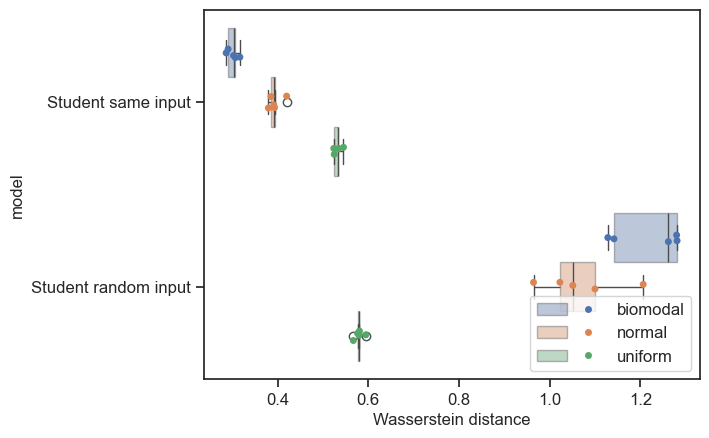

In [34]:
plt_data = data_EMD[data_EMD["model"].isin(['student_same_input', 'student_random_input'])]
ax=sns.boxplot(data=plt_data, y="model", x="EMD", hue="dist", boxprops={'alpha': 0.4},
              order=['student_same_input', 'student_random_input'])
sns.stripplot(y='model', x='EMD', data=plt_data, hue="dist", dodge=True, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[(handles[0], handles[3]),(handles[1], handles[4]), (handles[2], handles[5])],
          labels=['biomodal', 'normal', "uniform"],
          loc='lower right', handlelength=4,
          handler_map={tuple: HandlerTuple(ndivide=None)})
ax.set_yticklabels(labels=["Student same input", "Student random input"])
plt.xlabel("Wasserstein distance")
plt.savefig("/Users/adr/Box/BioFuzzNet/Figures/Init_distributions_EMD_boxplot_same_inputs_three_dists.pdf", bbox_inches="tight")